<table class="table table-bordered">
    <tr>
        <th style="text-align:center; width:25%"><img src='https://www.np.edu.sg/PublishingImages/Pages/default/odp/ICT.jpg' style="width: 250px; height: 125px; "></th>
        <th style="text-align:center;"><h1>Deep Learning</h1><h2>Assignment 2 - Sentiment Analysis Model (Problem 1)</h2><h3>AY2020/21 Semester</h3></th>
    </tr>
</table>

In [26]:
# Import the Required Packages
from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers
from tensorflow.keras import regularizers
from tensorflow.keras.layers import GRU, LSTM
from keras.regularizers import l2
from keras.regularizers import l1
import os
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense, Dropout
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

In [27]:
# Graph plotting function
def plot_graph(history):
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.figure()

    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

## Step 1 – Data Loading and Processing

### 1.1 Data Loading

In [28]:
# Load the emoji_dictionary
import pandas as pd
df = pd.read_csv('mapping.csv', delimiter=',')
emoji_dictionary = df.loc[:,'emoticons'].to_dict()
print(emoji_dictionary)
print('A total of: ', len(emoji_dictionary), 'Emoji Icons')

{0: '😍', 1: '😂', 2: '📷', 3: '🔥', 4: '❤'}
A total of:  5 Emoji Icons


In [29]:
# load the dataset
dat = pd.read_csv('data.txt', delimiter=',')
texts = dat.loc[:,'TEXT'].values
labels = dat.loc[:,'Label'].values

In [30]:
# Check the maximum length of texts
max_len = -1
for example in texts:
    if len(example.split()) > max_len:
        max_len = len(example.split())
        
print('the maximum length of the text inputs is ', max_len) #34 unchanged

the maximum length of the text inputs is  34


### 1.2 Data Processing


In [1]:
# Convert the texts and labels into numeric tensors

maxlen = 34
training_samples = len(texts)
# validation_samples = 5000 #math.floor(training_samples * 0.2)
max_words = 50000 # unique words in vocab list

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

data = pad_sequences(sequences, maxlen=maxlen, padding='post')

labels = np.asarray(labels)
print('Shape of data tensor:', data.shape)
print('Shape of label tensor:', labels.shape)

NameError: name 'texts' is not defined

### 1.3 Data Sampling

In [32]:
# Split the X & y into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state = 24)
# Refer the report Appendix
# Please enter the random_state assigned to your group
print("X_train", X_train.shape)
print("y_train", y_train.shape)
print("X_test", X_test.shape)
print("y_test", y_test.shape)

X_train (34036, 34)
y_train (34036,)
X_test (8510, 34)
y_test (8510,)


## Step 2 – Develop a Sentiment Analysis Model

### Model #1 (Replicate as necessary for other models)

In [33]:
glove_dir = 'glove.6B'

embeddings_index = {}
f = open(os.path.join(glove_dir, 'glove.6B.50d.txt'), encoding="utf8")
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embeddings_index[word] = coefs
f.close()

print('Found %s word vectors.' % len(embeddings_index))

embedding_dim = 50

embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if i < max_words:
        if embedding_vector is not None:
            # Words not found in embedding index will be all-zeros.
            embedding_matrix[i] = embedding_vector

Found 400000 word vectors.


In [36]:
# Build the Model 15

model = Sequential()
model.add(Embedding(max_words, embedding_dim, input_length=maxlen))
model.add(GRU(96, return_sequences=True, dropout=(0.5)))
model.add(GRU(48, return_sequences=True, dropout=(0.5)))
model.add(Flatten())
model.add(Dense(5, activation='softmax'))

model.layers[0].set_weights([embedding_matrix])
model.layers[0].trainable = True
model.summary()

Model: "sequential_8"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_8 (Embedding)      (None, 34, 50)            2500000   
_________________________________________________________________
gru_25 (GRU)                 (None, 34, 96)            42624     
_________________________________________________________________
gru_26 (GRU)                 (None, 34, 48)            21024     
_________________________________________________________________
flatten_5 (Flatten)          (None, 1632)              0         
_________________________________________________________________
dense_8 (Dense)              (None, 5)                 8165      
Total params: 2,571,813
Trainable params: 2,571,813
Non-trainable params: 0
_________________________________________________________________


In [37]:

# Train the Model
model.compile(optimizer=optimizers.RMSprop(lr=0.0016),
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])
# history = model.fit(X_train, y_train,
#                     epochs=25,
#                     batch_size=128,
#                     validation_split=0.2)

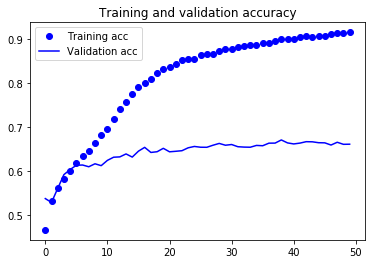

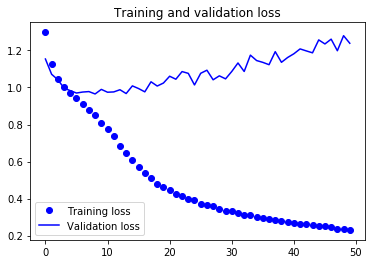

In [14]:
# Plot the Training and Validation Accuracy & Loss Scores
plot_graph(history)

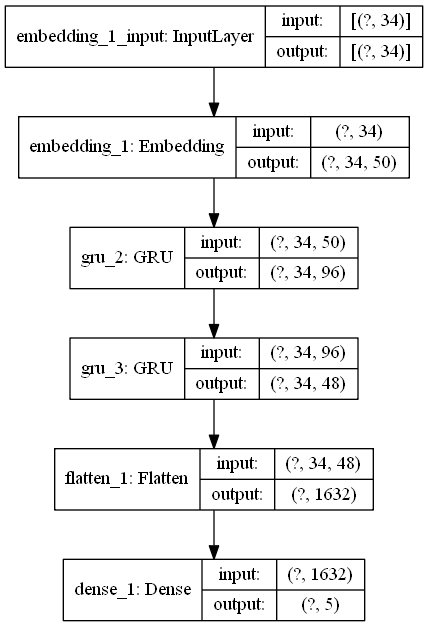

In [13]:
# Save the Model
# model.save('text_model_1_num15.h5')

from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True, to_file='model.png')

## Step 3 – Evaluate the Model using Testing Data 

In [38]:
# Model #1 (replicate where necessary for other models)
model.load_weights('text_model_1_num15.h5')
testResult = model.evaluate(X_test, y_test)
print(testResult)

8510/8510 [==============================] - 4s 468us/sample - loss: 1.0202 - acc: 0.6663
[1.0201875050675855, 0.66627496]


In [ ]:
# Save the Best Model
# model.save('text_model_best.h5')

## Step 4 – Use the Best Model to make prediction

In [ ]:
# model.load_weights('text_model_best.h5')

In [52]:
# takes the user input
testList = []
userInput = input("Please enter an input: ")
testList.append(userInput)
# print(testList)

seq = tokenizer.texts_to_sequences(testList)
test = pad_sequences(seq, maxlen=maxlen, padding="post")
# print(test)
resultTest = model.predict_classes(test)
# print(resultTest)
for emoji in emoji_dictionary:
    if resultTest == emoji:
        print(emoji_dictionary.get(emoji))

Please enter an input: shoutani
😂


In [ ]:
# convert the user input into numeric tensor


In [ ]:
# show the model output using predict function
